In [1]:
"""
WSOD with Dedicated Spatial Attention Module
Freezes backbone, trains only spatial attention layer + FC
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import timm
import cv2

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ============================================================================
# Spatial Attention Module
# ============================================================================

class SpatialAttentionModule(nn.Module):
    """
    Learnable spatial attention module
    Takes features from backbone and outputs spatial attention weights
    """
    def __init__(self, in_channels=2048, reduction=8):
        super(SpatialAttentionModule, self).__init__()
        
        # Spatial attention pathway
        self.conv1 = nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(in_channels // reduction)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(in_channels // reduction, in_channels // reduction, 
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels // reduction)
        
        # Output attention map
        self.conv_out = nn.Conv2d(in_channels // reduction, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        Args:
            x: [B, 2048, 7, 7] features from backbone
        Returns:
            attention: [B, 1, 7, 7] spatial attention map
            weighted_features: [B, 2048, 7, 7] attention-weighted features
        """
        # Generate spatial attention
        att = self.conv1(x)
        att = self.bn1(att)
        att = self.relu(att)
        
        att = self.conv2(att)
        att = self.bn2(att)
        att = self.relu(att)
        
        att = self.conv_out(att)
        attention = self.sigmoid(att)  # [B, 1, 7, 7]
        
        # Apply attention to features
        weighted_features = x * attention
        
        return attention, weighted_features

In [3]:
# ============================================================================
# WSOD Model with Spatial Attention
# ============================================================================

# Wrapper with spatial attention inserted AFTER stage4 (before final transformer)
class WSODResViT(nn.Module):
    def __init__(self, base_model, num_classes=2):
        super(WSODResViT, self).__init__()
        
        # Frozen components from base model
        self.stem = base_model.stem
        self.stage1 = base_model.stage1
        self.trans1 = base_model.trans1
        self.stage2 = base_model.stage2
        self.trans2 = base_model.trans2
        self.stage3 = base_model.stage3
        self.trans3 = base_model.trans3
        self.stage4 = base_model.stage4
        
        # Add TRAINABLE spatial attention here (after stage4, before trans4)
        self.spatial_attention = SpatialAttentionModule(in_channels=2048)
        
        # Frozen transformer and classifier
        self.trans4 = base_model.trans4
        self.global_pool = base_model.global_pool
        
        # TRAINABLE classifier
        self.classifier = nn.Linear(2048, num_classes)
        self.classifier.weight.data.copy_(base_model.classifier.weight.data)
        self.classifier.bias.data.copy_(base_model.classifier.bias.data)
        
    def forward(self, x, return_attention=False):
        # Frozen ResNet stages with transformers
        x = self.stem(x)
        x = self.stage1(x)
        x = self.trans1(x)
        x = self.stage2(x)
        x = self.trans2(x)
        x = self.stage3(x)
        x = self.trans3(x)
        x = self.stage4(x)  # [B, 2048, 7, 7]
        
        # TRAINABLE spatial attention
        attention_map, x = self.spatial_attention(x)
        
        # Frozen final transformer
        x = self.trans4(x)
        
        # Pool and classify
        x = self.global_pool(x)
        x = x.flatten(1)
        x = self.classifier(x)  # TRAINABLE
        
        if return_attention:
            return x, attention_map
        return x
    
    def get_attention_map(self, x):
        with torch.no_grad():
            x = self.stem(x)
            x = self.stage1(x)
            x = self.trans1(x)
            x = self.stage2(x)
            x = self.trans2(x)
            x = self.stage3(x)
            x = self.trans3(x)
            x = self.stage4(x)
            attention_map, _ = self.spatial_attention(x)
        return attention_map

In [4]:
# ============================================================================
# Attention-based Loss Functions
# ============================================================================

def bbox_to_gaussian_mask(bbox, target_size=(7, 7), sigma_scale=1.0):
    """
    Convert bounding box to Gaussian mask for soft attention guidance
    """
    batch_size = bbox.shape[0]
    h, w = target_size
    
    # Create coordinate grids
    y_coords = torch.linspace(0, 1, h, device=bbox.device).view(-1, 1).expand(h, w)
    x_coords = torch.linspace(0, 1, w, device=bbox.device).view(1, -1).expand(h, w)
    
    masks = []
    for i in range(batch_size):
        x, y, box_w, box_h = bbox[i]
        
        # Center of bounding box
        cx = x + box_w / 2
        cy = y + box_h / 2
        
        # Sigma based on box size
        sigma_x = (box_w / 2) * sigma_scale
        sigma_y = (box_h / 2) * sigma_scale
        
        # Prevent division by zero
        sigma_x = max(sigma_x, 0.05)
        sigma_y = max(sigma_y, 0.05)
        
        # Gaussian formula
        gaussian = torch.exp(
            -((x_coords - cx) ** 2) / (2 * sigma_x ** 2) -
            ((y_coords - cy) ** 2) / (2 * sigma_y ** 2)
        )
        
        masks.append(gaussian)
    
    return torch.stack(masks).unsqueeze(1)  # [B, 1, H, W]


def spatial_attention_loss(attention_map, bbox, label, sigma_scale=1.0):
    """
    Direct supervision for spatial attention module
    Only applied to positive samples (nodules present)
    """
    # Only compute loss for positive samples
    positive_mask = label == 1
    
    if positive_mask.sum() == 0:
        return torch.tensor(0.0, device=attention_map.device)
    
    # Get positive samples
    pos_attention = attention_map[positive_mask]
    pos_bbox = bbox[positive_mask]
    
    # Generate Gaussian masks from bboxes (at native resolution 7x7)
    target_size = (pos_attention.shape[2], pos_attention.shape[3])
    gaussian_masks = bbox_to_gaussian_mask(pos_bbox, target_size, sigma_scale)
    
    # MSE loss between attention and Gaussian mask
    mse_loss = F.mse_loss(pos_attention, gaussian_masks)
    
    # KL divergence loss (treating as probability distributions)
    attention_prob = pos_attention / (pos_attention.sum(dim=(2, 3), keepdim=True) + 1e-8)
    target_prob = gaussian_masks / (gaussian_masks.sum(dim=(2, 3), keepdim=True) + 1e-8)
    
    kl_loss = F.kl_div(
        (attention_prob + 1e-8).log(), 
        target_prob, 
        reduction='batchmean'
    )
    
    # Combine losses
    total_loss = 0.5 * mse_loss + 0.5 * kl_loss
    
    return total_loss

In [5]:
# ============================================================================
# Training Functions
# ============================================================================

def train_epoch_wsod(model, loader, criterion, optimizer, device, attention_weight=0.5, sigma_scale=1.0):
    model.train()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_att_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training WSOD')
    for images, labels, bboxes in pbar:
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with attention
        outputs, attention_map = model(images, return_attention=True)
        
        # Classification loss
        cls_loss = criterion(outputs, labels)
        
        # Spatial attention loss (direct supervision on attention module)
        att_loss = spatial_attention_loss(attention_map, bboxes, labels, sigma_scale)
        
        # Total loss
        loss = cls_loss + attention_weight * att_loss
        
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        running_cls_loss += cls_loss.item()
        running_att_loss += att_loss.item()
        
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        pbar.set_postfix({
            'loss': running_loss/len(pbar),
            'cls': running_cls_loss/len(pbar),
            'att': running_att_loss/len(pbar),
            'acc': 100.*correct/total
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_cls_loss = running_cls_loss / len(loader)
    epoch_att_loss = running_att_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_cls_loss, epoch_att_loss, epoch_acc, all_preds, all_labels, all_probs


def validate_wsod(model, loader, criterion, device, attention_weight=0.5, sigma_scale=1.0):
    model.eval()
    running_loss = 0.0
    running_att_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
            
            outputs, attention_map = model(images, return_attention=True)
            loss = criterion(outputs, labels)
            
            # Calculate attention loss for monitoring
            att_loss = spatial_attention_loss(attention_map, bboxes, labels, sigma_scale)
            
            running_loss += loss.item()
            running_att_loss += att_loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_att_loss = running_att_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    binary_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_att_loss, epoch_acc, all_preds, all_labels, all_probs, binary_precision, binary_recall, binary_f1, binary_auc


In [6]:
# ============================================================================
# Visualization Functions
# ============================================================================

def visualize_attention_with_bbox(model, image, bboxes, label, pred, denormalize=True):
    """
    Visualize attention map overlaid on image with GT bbox(es)
    """
    model.eval()
    
    # Denormalize image
    if denormalize:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_display = image.cpu() * std + mean
        image_display = image_display.clamp(0, 1)
    else:
        image_display = image.cpu()
    
    # Get attention map
    with torch.no_grad():
        attention_map = model.get_attention_map(image.unsqueeze(0).to(device))
        attention_map = attention_map.squeeze().cpu().numpy()
    
    # Resize attention to match image
    attention_resized = cv2.resize(attention_map, (224, 224))
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    img_np = image_display.permute(1, 2, 0).numpy()
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original\nGT: {label}, Pred: {pred}')
    axes[0].axis('off')
    
    # Attention heatmap
    axes[1].imshow(img_np)
    im = axes[1].imshow(attention_resized, cmap='jet', alpha=0.5)
    axes[1].set_title('Spatial Attention')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    
    # With bounding box(es)
    axes[2].imshow(img_np)
    axes[2].imshow(attention_resized, cmap='jet', alpha=0.5)
    
    # Draw bbox(es) if nodule is present
    if label == 1:
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        
        for idx, bbox in enumerate(bboxes):
            x, y, w, h = bbox.cpu().numpy()
            x_pix = x * 224
            y_pix = y * 224
            w_pix = w * 224
            h_pix = h * 224
            
            color = 'lime'
            rect = plt.Rectangle(
                (x_pix, y_pix), w_pix, h_pix,
                fill=False, edgecolor=color, linewidth=2
            )
            axes[2].add_patch(rect)
        
        axes[2].legend([f'GT BBox ({len(bboxes)} nodule{"s" if len(bboxes) > 1 else ""})'])
    
    axes[2].set_title('Attention + GT BBox')
    axes[2].axis('off')
    
    plt.tight_layout()
    return fig

print("=" * 80)
print("Setup complete with Spatial Attention Module!")
print("=" * 80)

Setup complete with Spatial Attention Module!


In [7]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BATCH_SIZE = 16
NUM_EPOCHS = 50  
LEARNING_RATE = 5e-5  
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01
ATTENTION_WEIGHT = 0.3  
SIGMA_SCALE = 1.3  

# Paths
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"
checkpoint_path = "./resnet50_binary.pth"

train_images_path = f"{split_base_path}/train/images"
val_images_path = f"{split_base_path}/val/images"
test_images_path = f"{split_base_path}/test/images"

train_csv_path = f"{split_base_path}/train/metadata_no_aug.csv"
val_csv_path = f"{split_base_path}/val/metadata_val.csv"
test_csv_path = f"{split_base_path}/test/metadata_test.csv"

In [8]:
# ============================================================================
# LOAD DATA
# ============================================================================

print("\nLoading datasets...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with bbox
from NoduleDS import NoduleDataset

train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)



Loading datasets...
Train samples: 3657
Val samples: 782
Test samples: 785


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class TransformerBlock(nn.Module):
    """Ultra-lightweight Transformer block with spatial downsampling"""
    def __init__(self, dim, num_heads=2, mlp_ratio=1.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        B, C, H, W = x.shape
        
        # OPTIMIZATION: Downsample spatial dims for attention if too large
        if H * W > 196:  # If feature map > 14x14
            x_down = F.adaptive_avg_pool2d(x, (14, 14))
            B_d, C_d, H_d, W_d = x_down.shape
            x_seq = x_down.flatten(2).transpose(1, 2)
        else:
            x_seq = x.flatten(2).transpose(1, 2)
            H_d, W_d = H, W
        
        # Multi-head self-attention with residual
        x_norm = self.norm1(x_seq)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x_seq = x_seq + attn_out
        
        # MLP with residual
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        
        # Reshape back
        x_out = x_seq.transpose(1, 2).reshape(B, C, H_d, W_d)
        
        # Upsample back if needed
        if H_d != H or W_d != W:
            x_out = F.interpolate(x_out, size=(H, W), mode='bilinear', align_corners=False)
        
        return x + x_out  # Residual from original

class ResNetWithMultiScaleAttention(nn.Module):
    """ResNet-50 with lightweight transformer blocks at multiple scales"""
    def __init__(self, num_classes=2, pretrained=True, num_heads=2, dropout=0.1):
        super().__init__()
        
        # Load pretrained ResNet-50
        backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        
        # Extract ResNet stages
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.act1,
            backbone.maxpool
        )
        self.stage1 = backbone.layer1  # Output: 256 channels, H/4 x W/4 (56x56 for 224 input)
        self.stage2 = backbone.layer2  # Output: 512 channels, H/8 x W/8 (28x28)
        self.stage3 = backbone.layer3  # Output: 1024 channels, H/16 x W/16 (14x14)
        self.stage4 = backbone.layer4  # Output: 2048 channels, H/32 x W/32 (7x7)
        
        # Add ultra-lightweight transformer blocks after each stage
        # Using minimal heads and MLP ratio to keep it fast
        self.trans1 = TransformerBlock(256, num_heads=2, mlp_ratio=1.0, dropout=dropout)
        self.trans2 = TransformerBlock(512, num_heads=2, mlp_ratio=1.0, dropout=dropout)
        self.trans3 = TransformerBlock(1024, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout)
        self.trans4 = TransformerBlock(2048, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout)
        
        # Global average pooling and classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(2048, num_classes)
        
    def forward(self, x):
        # Stem
        x = self.stem(x)
        
        # Stage 1 + Transformer
        x = self.stage1(x)
        x = self.trans1(x)
        
        # Stage 2 + Transformer
        x = self.stage2(x)
        x = self.trans2(x)
        
        # Stage 3 + Transformer
        x = self.stage3(x)
        x = self.trans3(x)
        
        # Stage 4 + Transformer
        x = self.stage4(x)
        x = self.trans4(x)
        
        # Global pooling and classification
        x = self.global_pool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        
        return x

In [10]:
# ============================================================================
# LOAD PRETRAINED MODEL & SETUP WSOD WITH SPATIAL ATTENTION
# ============================================================================

print("\nLoading pretrained checkpoint...")
base_model = ResNetWithMultiScaleAttention(num_classes=2, pretrained=False, num_heads=2, dropout=0.1)
checkpoint_path = "./resvit-two-scale.pth"

# Load your ResViT checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)
if 'model_state_dict' in checkpoint:
    base_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Previous val_acc: {checkpoint.get('val_acc', 'unknown'):.2f}%")
else:
    base_model.load_state_dict(checkpoint)
    print("Loaded model weights")

# Freeze entire base model
# for param in base_model.parameters():
#     param.requires_grad = False
# print("✓ Entire ResViT model (ResNet + Transformers) frozen")

# Create model with spatial attention module
model = WSODResViT(base_model, num_classes=2).to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")
print("Architecture: ResNet stages + Transformers (frozen) → Spatial Attention (trainable) → Final Transformer (frozen) → Classifier (trainable)")


# Calculate class weights
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"Class weights: {class_weights}")

# Loss and optimizer - only spatial attention + FC are trainable
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,  # Higher LR since we're only training small modules
    weight_decay=0.01
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("\nModel ready for WSOD fine-tuning with Spatial Attention!")


Loading pretrained checkpoint...
Loaded checkpoint from epoch 16
Previous val_acc: 94.50%

Trainable parameters: 58,089,795 / 58,089,795 (100.0%)
Architecture: ResNet stages + Transformers (frozen) → Spatial Attention (trainable) → Final Transformer (frozen) → Classifier (trainable)
Class weights: tensor([0.6971, 1.7684], device='cuda:0')

Model ready for WSOD fine-tuning with Spatial Attention!


In [11]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "=" * 80)
print("Starting WSOD Fine-tuning")
print("=" * 80)

history = {
    'train_loss': [], 'train_cls_loss': [], 'train_att_loss': [],
    'train_acc': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_f1': [], 'val_precision': [], 'val_recall': []
}

best_val_att_loss = float('inf')
best_val_precision = 0.0
best_val_recall = 0.0
best_model_path = 'best_wsod_resvit.pth'

# Thresholds for "good enough" clinical performance
MIN_PRECISION = 0.90
MIN_RECALL = 0.90

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 80)
    
    # Train
    train_loss, train_cls_loss, train_att_loss, train_acc, train_preds, train_labels, train_probs = train_epoch_wsod(
        model, train_loader, criterion, optimizer, device, ATTENTION_WEIGHT, SIGMA_SCALE
    )
    
    train_auc = roc_auc_score(train_labels, train_probs)
    
    # Validate
    val_loss, val_att_loss, val_acc, val_preds, val_labels, val_probs, val_prec, val_recall, val_f1, val_auc = validate_wsod(
        model, val_loader, criterion, device, ATTENTION_WEIGHT, SIGMA_SCALE
    )
    
    # Step scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_cls_loss'].append(train_cls_loss)
    history['train_att_loss'].append(train_att_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_recall)
    
    print(f"\nTrain - Loss: {train_loss:.4f} (Cls: {train_cls_loss:.4f}, Att: {train_att_loss:.4f})")
    print(f"Train - Acc: {train_acc:.2f}%, AUC: {train_auc:.4f}")
    print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, AUC: {val_auc:.4f}")
    print(f"Val   - Precision: {val_prec:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model: if precision and recall are both excellent, optimize for attention
    if val_prec >= MIN_PRECISION and val_recall >= MIN_RECALL:
        if val_att_loss < best_val_att_loss:
            best_val_att_loss = val_att_loss
            best_val_precision = val_prec
            best_val_recall = val_recall
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_auc': val_auc,
                'val_f1': val_f1,
                'val_precision': val_prec,
                'val_recall': val_recall,
                'val_att_loss': val_att_loss,
            }, best_model_path)
            print(f"✓ Saved best model - excellent performance with better attention!")
            print(f"  Precision: {val_prec:.4f}, Recall: {val_recall:.4f}, AttLoss: {val_att_loss:.4f}")
    else:
        # Fallback: save if we're improving toward the thresholds
        if val_prec > best_val_precision or val_recall > best_val_recall:
            if val_prec >= best_val_precision and val_recall >= best_val_recall:
                best_val_precision = val_prec
                best_val_recall = val_recall
                best_val_att_loss = val_att_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_auc': val_auc,
                    'val_f1': val_f1,
                    'val_precision': val_prec,
                    'val_recall': val_recall,
                    'val_att_loss': val_att_loss,
                }, best_model_path)
                print(f"✓ Saved model - improving precision/recall")
                print(f"  Precision: {val_prec:.4f}, Recall: {val_recall:.4f}")

print("\n" + "=" * 80)
print("Training completed!")
print(f"Best Precision: {best_val_precision:.4f}, Best Recall: {best_val_recall:.4f}")
print(f"Best Attention Loss: {best_val_att_loss:.4f}")
print("=" * 80)


Starting WSOD Fine-tuning

Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:13<00:00,  3.69it/s]



Train - Loss: 1.3383 (Cls: 0.8600, Att: 1.5945)
Train - Acc: 63.08%, AUC: 0.6495
Val   - Loss: 0.5413, Acc: 73.66%, AUC: 0.7497
Val   - Precision: 0.5872, Recall: 0.2844, F1: 0.3832
LR: 0.000300
✓ Saved model - improving precision/recall
  Precision: 0.5872, Recall: 0.2844

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:12<00:00,  3.80it/s]



Train - Loss: 1.0779 (Cls: 0.6993, Att: 1.2620)
Train - Acc: 67.35%, AUC: 0.7210
Val   - Loss: 0.7437, Acc: 63.30%, AUC: 0.7749
Val   - Precision: 0.4299, Recall: 0.8444, F1: 0.5697
LR: 0.000299

Epoch 3/50
--------------------------------------------------------------------------------


...


Train - Loss: 0.7592 (Cls: 0.4351, Att: 1.0804)
Train - Acc: 81.46%, AUC: 0.8838
Val   - Loss: 0.3878, Acc: 81.59%, AUC: 0.9026
Val   - Precision: 0.6364, Recall: 0.8400, F1: 0.7241
LR: 0.000023

Epoch 42/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:17<00:00,  2.88it/s]



Train - Loss: 0.7643 (Cls: 0.4357, Att: 1.0951)
Train - Acc: 81.93%, AUC: 0.8906
Val   - Loss: 0.4304, Acc: 79.80%, AUC: 0.9106
Val   - Precision: 0.5971, Recall: 0.9156, F1: 0.7228
LR: 0.000019

Epoch 43/50
--------------------------------------------------------------------------------


Training WSOD:  59%|█████▉    | 135/229 [00:47<00:33,  2.81it/s, loss=0.438, cls=0.244, att=0.647, acc=82.9]   


KeyboardInterrupt: 

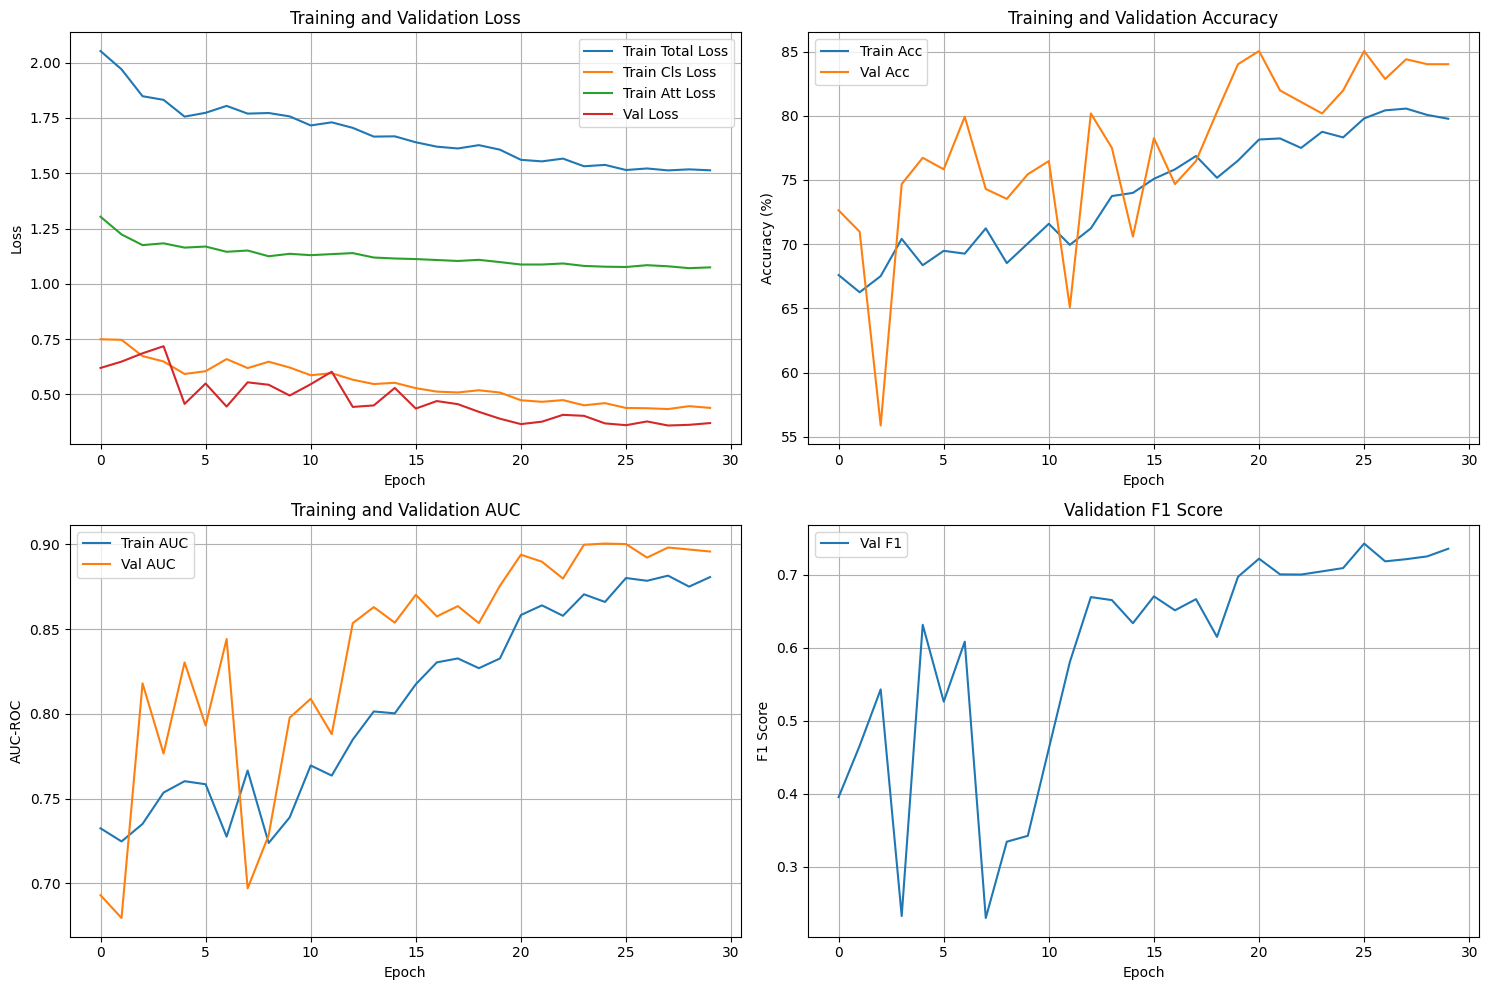

Training curves saved to 'wsod_training_history.png'


In [ ]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Total Loss')
axes[0, 0].plot(history['train_cls_loss'], label='Train Cls Loss')
axes[0, 0].plot(history['train_att_loss'], label='Train Att Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Acc')
axes[0, 1].plot(history['val_acc'], label='Val Acc')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[1, 0].plot(history['train_auc'], label='Train AUC')
axes[1, 0].plot(history['val_auc'], label='Val AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC-ROC')
axes[1, 0].set_title('Training and Validation AUC')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('wsod_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to 'wsod_training_history.png'")

In [ ]:
# ============================================================================
# LOAD BEST MODEL FOR TESTING
# ============================================================================

print("\n" + "=" * 80)
print("Loading best model for testing...")
print("=" * 80)

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best val F1: {checkpoint['val_f1']:.4f}")


Loading best model for testing...
Loaded best model from epoch 26
Best val F1: 0.7429


In [ ]:
# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\nEvaluating on test set...")

# Validate
test_loss, test_att_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_recall, test_f1, test_auc = validate_wsod(
    model, test_loader, criterion, device, ATTENTION_WEIGHT, SIGMA_SCALE
)

print("\n" + "=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test AUC-ROC: {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)



Evaluating on test set...


Validation: 100%|██████████| 50/50 [00:15<00:00,  3.15it/s]


TEST SET RESULTS
Test Loss: 0.3261
Test Accuracy: 85.48%
Test AUC-ROC: 0.9177
Test Precision: 0.7229
Test Recall: 0.7696
Test F1 Score: 0.7455

Confusion Matrix:
[[504  64]
 [ 50 167]]



Generating Attention Visualizations on Test Set
Selected random indices: [204 360 170 197 457  70]


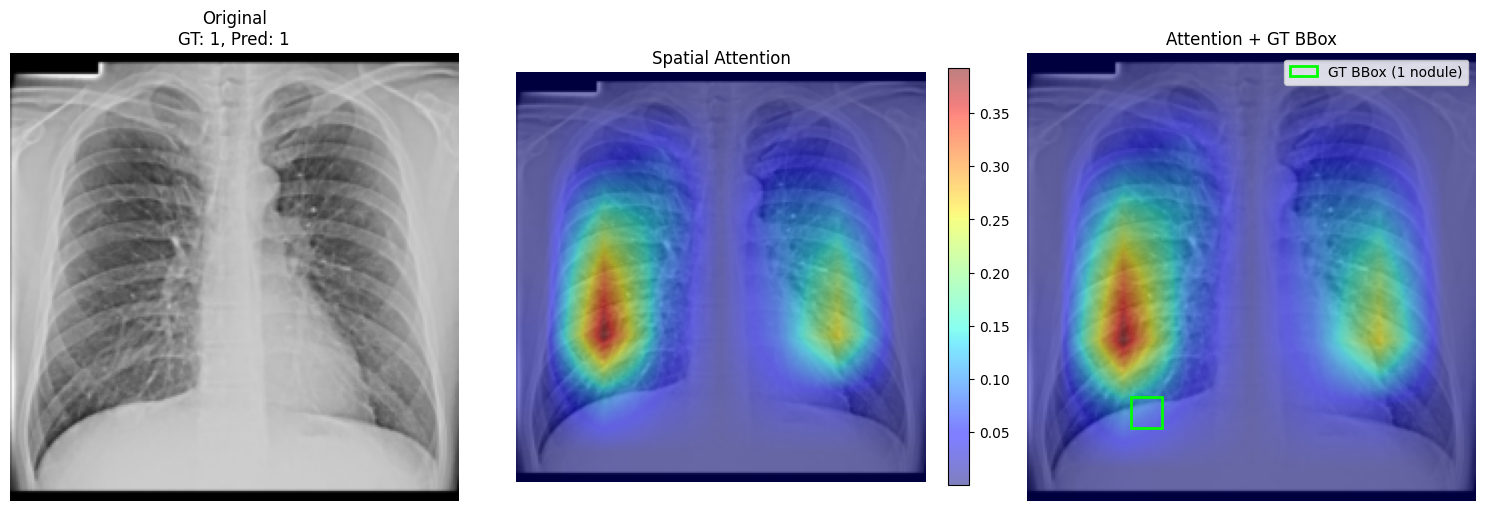

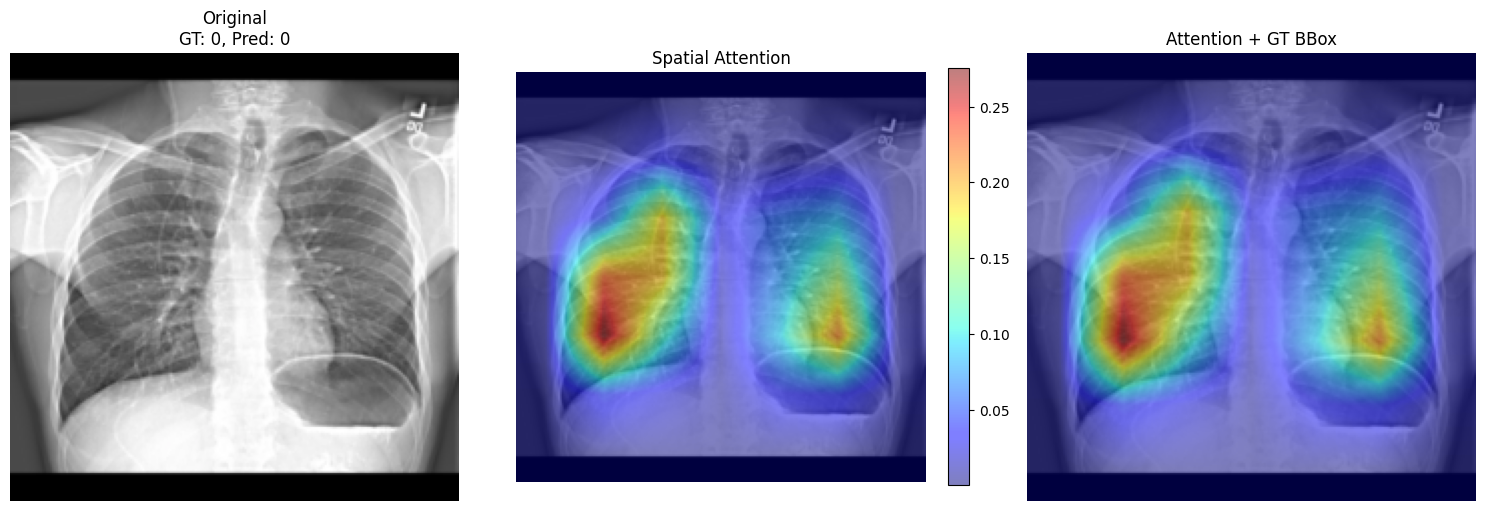

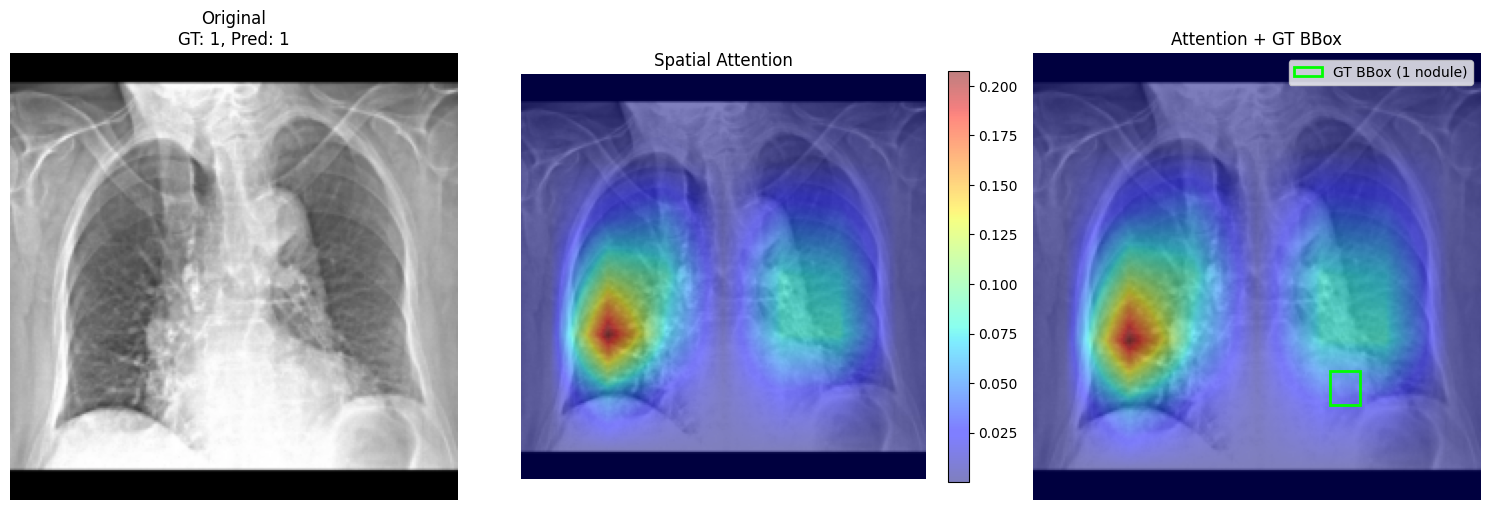

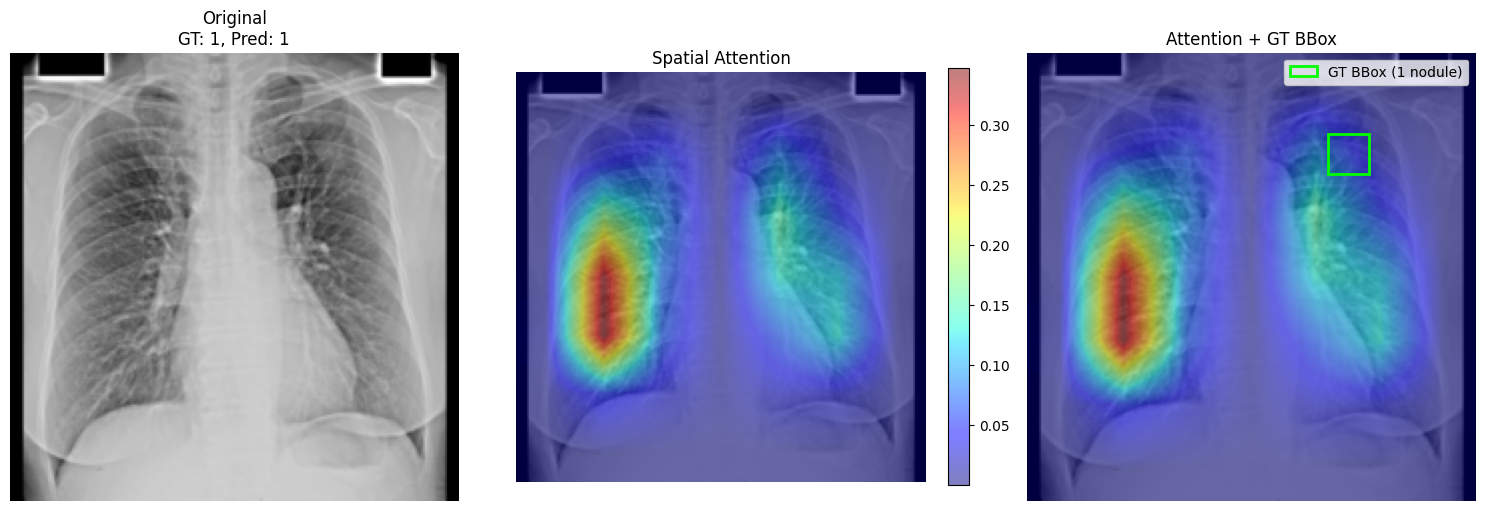

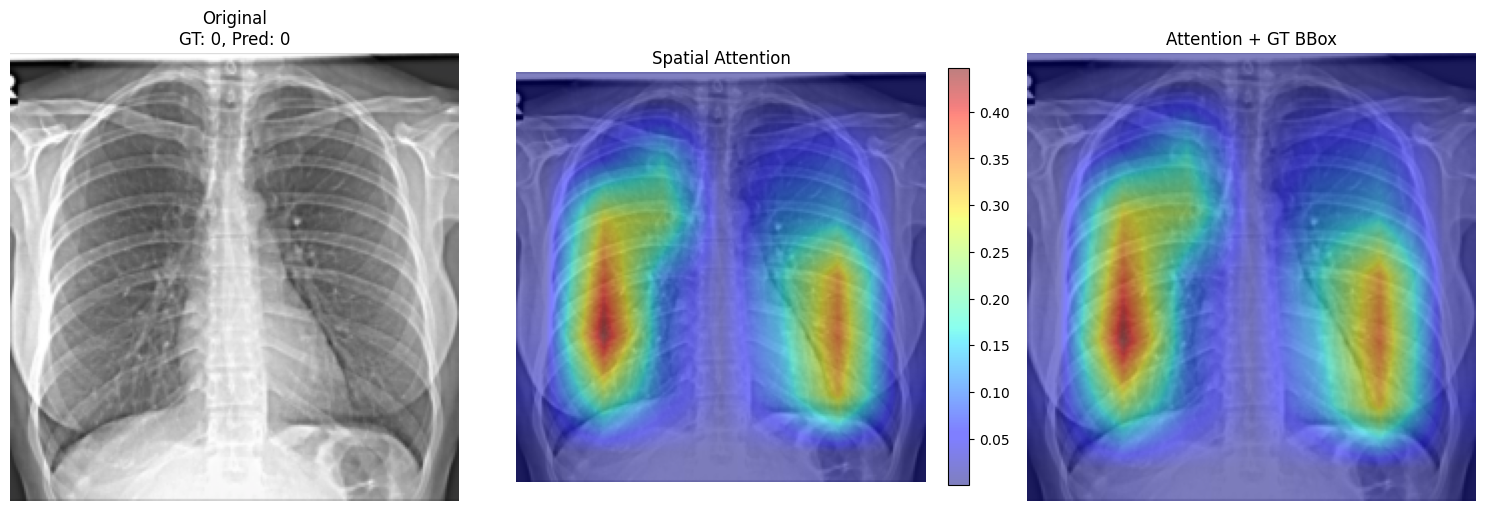

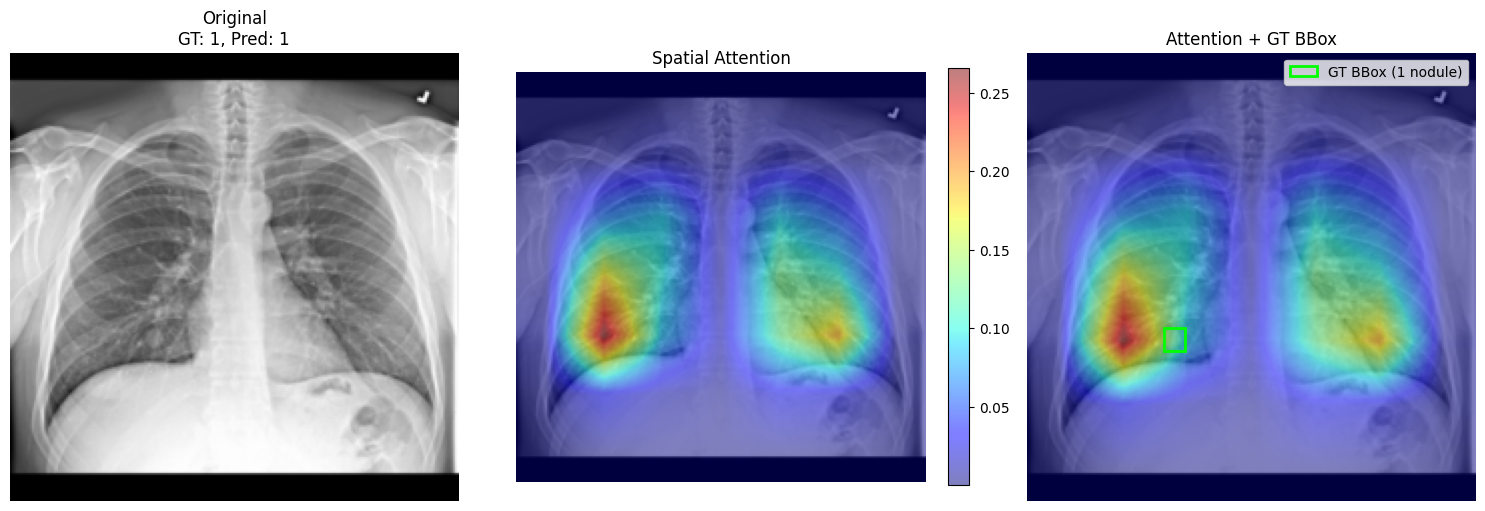


Visualized 6 random test samples with attention maps
Note: Images with multiple nodules will show one bbox per visualization


In [ ]:
# ============================================================================
# VISUALIZE ATTENTION MAPS ON TEST SET
# ============================================================================

print("\n" + "=" * 80)
print("Generating Attention Visualizations on Test Set")
print("=" * 80)

model.eval()

# Get random samples from test dataset
num_samples = 6
random_indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

print(f"Selected random indices: {random_indices}")

for idx in random_indices:
    img, label, bbox = test_dataset[idx]
    
    # Get prediction
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = output.argmax(1).item()
    
    # Visualize
    subfig = visualize_attention_with_bbox(model, img, bbox, label, pred)
    plt.show()
    
print(f"\nVisualized {num_samples} random test samples with attention maps")
print("Note: Images with multiple nodules will show one bbox per visualization")



Finding positive samples (with nodules) for visualization...
Found 165 unique positive patients in test set
Visualizing 8 random positive patients...

Patient: n0475.mha
  Added bbox: pixel=[163, 701, 85, 75] -> norm=[0.159, 0.685, 0.083, 0.073]
Found 1 nodule(s)


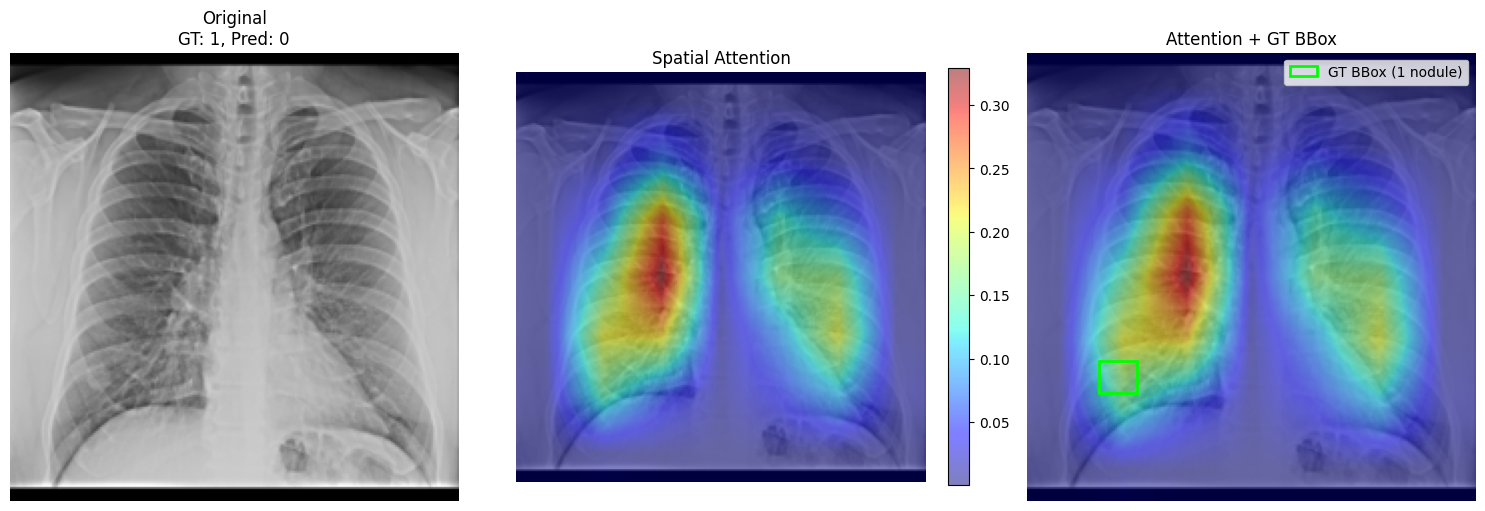


Patient: n1069.mha
  Added bbox: pixel=[696, 642, 32, 30] -> norm=[0.680, 0.627, 0.031, 0.029]
Found 1 nodule(s)


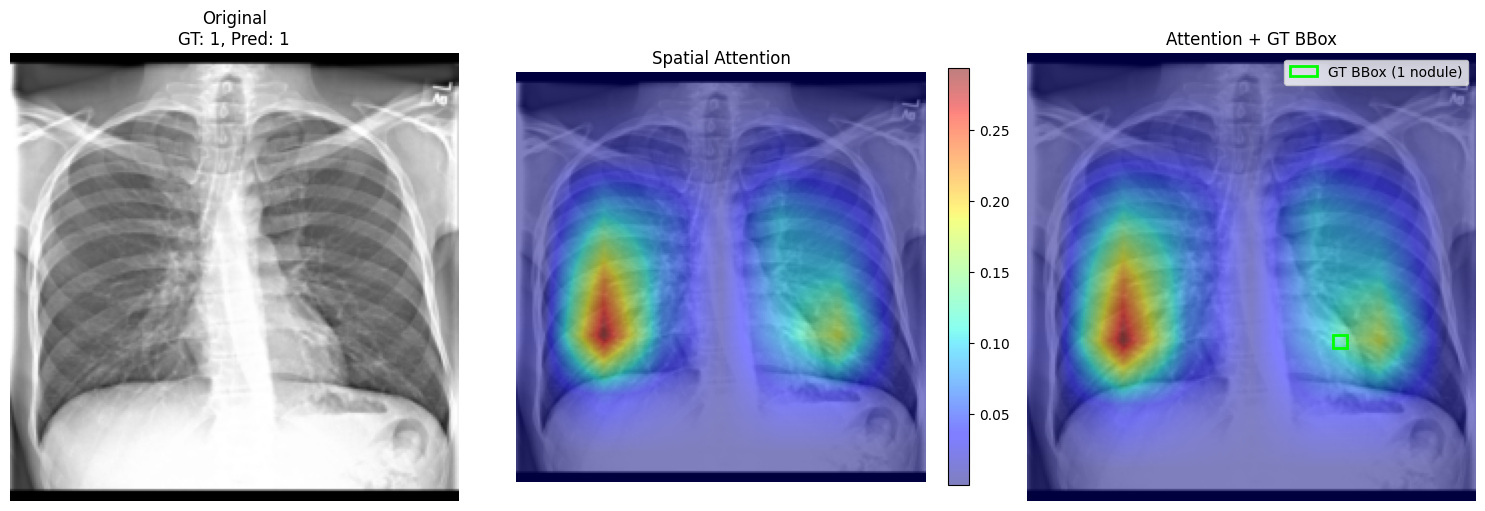


Patient: n1132.mha
  Added bbox: pixel=[257, 700, 39, 27] -> norm=[0.251, 0.684, 0.038, 0.026]
  Added bbox: pixel=[166, 662, 71, 60] -> norm=[0.162, 0.646, 0.069, 0.059]
  Added bbox: pixel=[261, 342, 42, 29] -> norm=[0.255, 0.334, 0.041, 0.028]
Found 3 nodule(s)


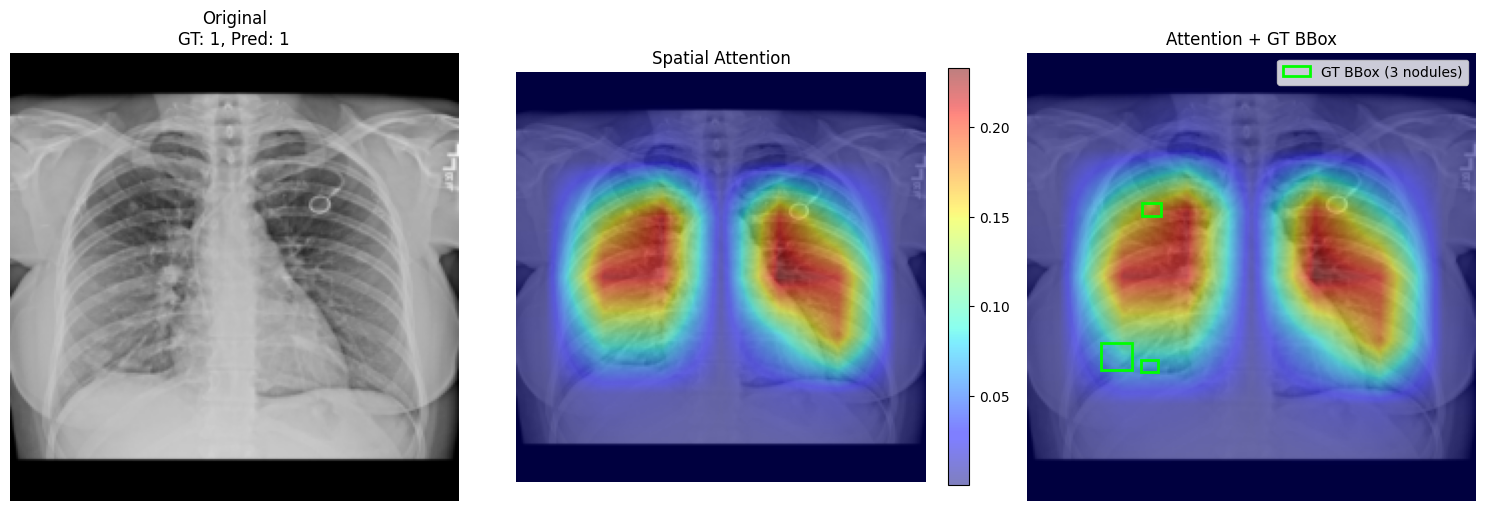


Patient: n0581.mha
  Added bbox: pixel=[657, 687, 44, 52] -> norm=[0.642, 0.671, 0.043, 0.051]
Found 1 nodule(s)


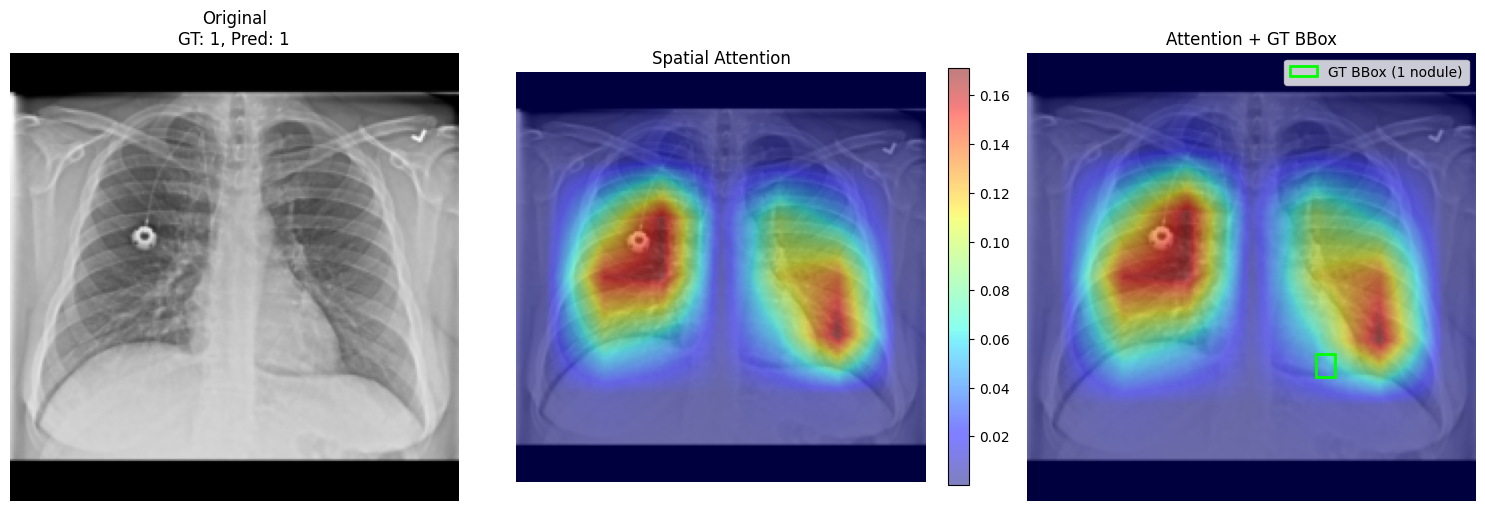


Patient: n0456.mha
  Added bbox: pixel=[535, 664, 109, 103] -> norm=[0.522, 0.648, 0.106, 0.101]
Found 1 nodule(s)


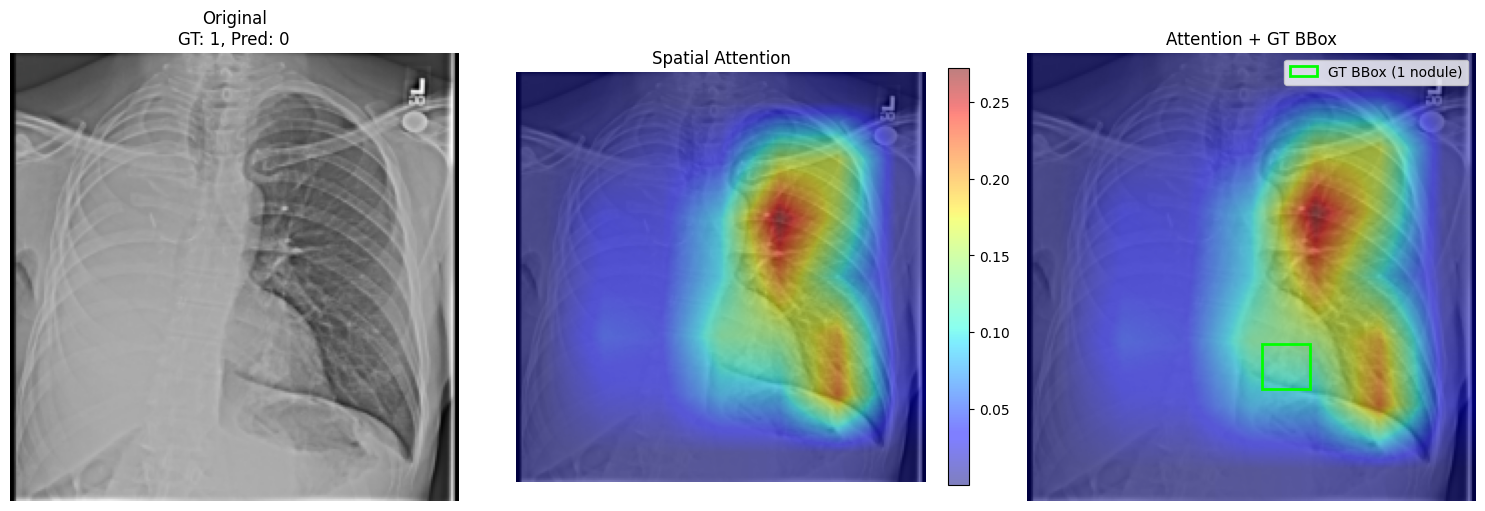


Patient: n1127.mha
  Added bbox: pixel=[791, 574, 63, 58] -> norm=[0.772, 0.561, 0.062, 0.057]
Found 1 nodule(s)


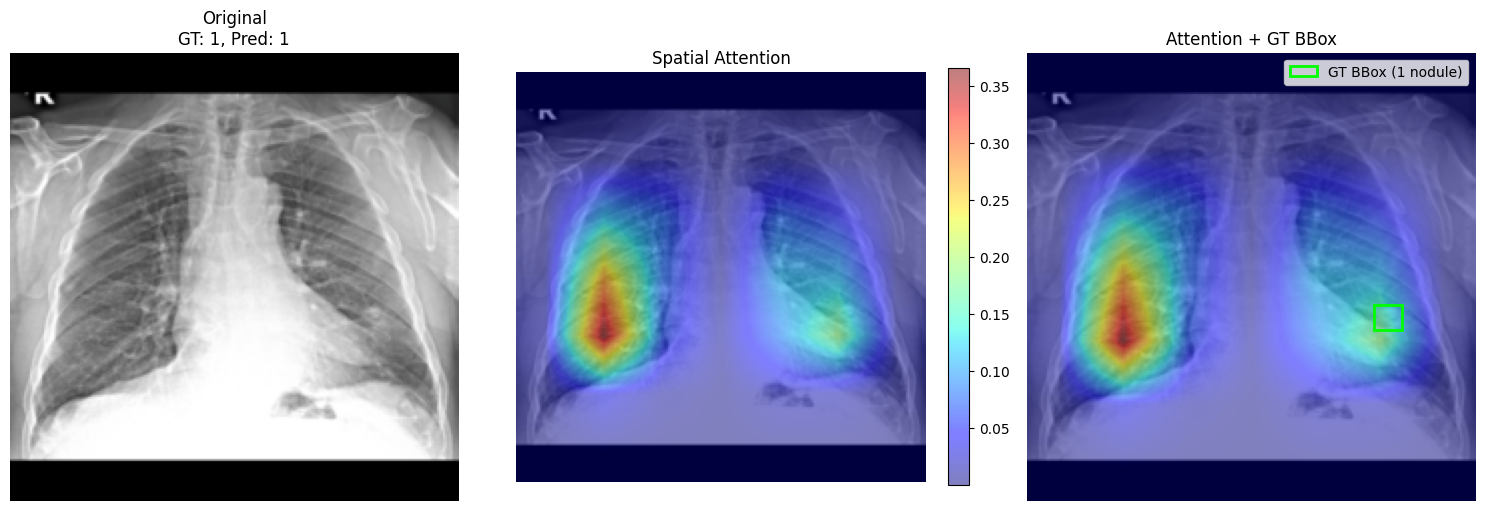


Patient: n0116.mha
  Added bbox: pixel=[153, 726, 46, 49] -> norm=[0.149, 0.709, 0.045, 0.048]
Found 1 nodule(s)


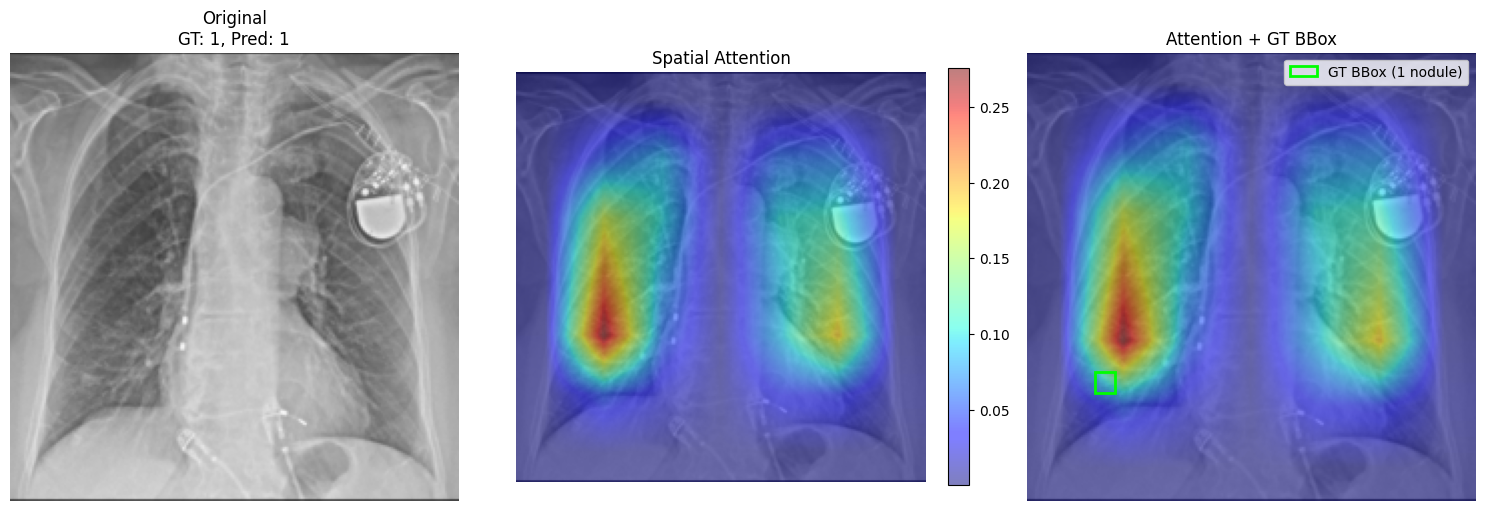


Patient: n0700.mha
  Added bbox: pixel=[744, 237, 62, 64] -> norm=[0.727, 0.231, 0.061, 0.062]
Found 1 nodule(s)


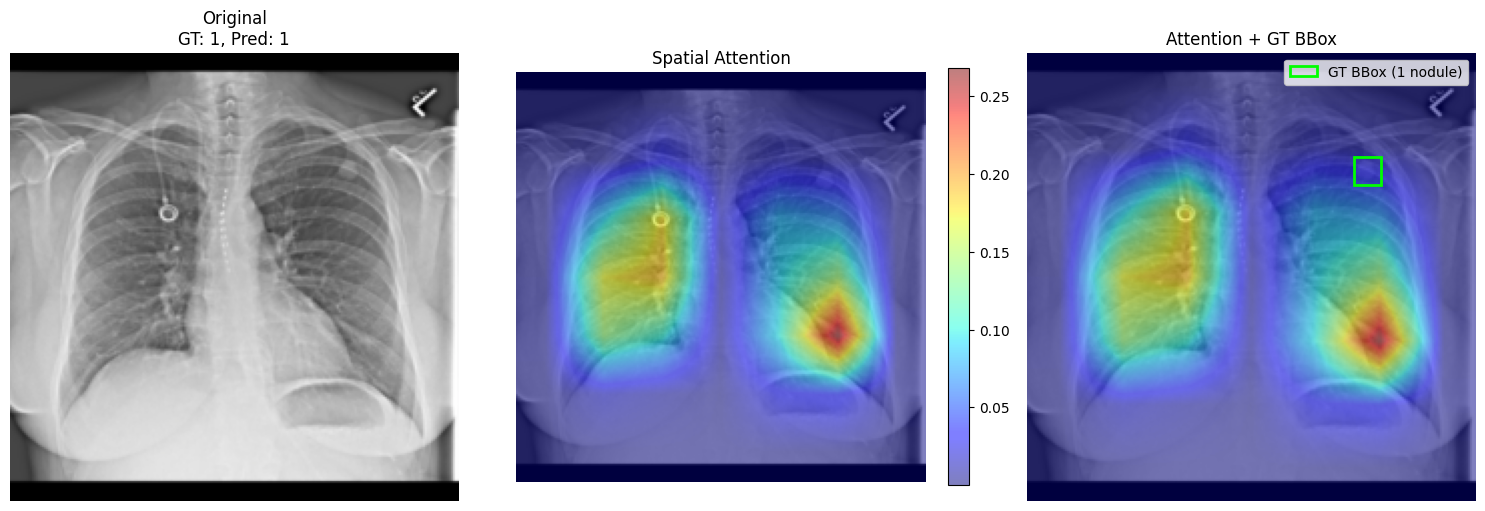


Displayed attention visualizations for 8 unique positive patients
Each visualization shows ALL nodules for that patient

WSOD Fine-tuning Complete!

Best model saved to: best_wsod_resvit.pth
Final Test AUC: 0.9177
Final Test F1: 0.7455


In [ ]:
# ============================================================================
# VISUALIZE POSITIVE SAMPLES (NODULES) - WITH MULTIPLE BBOXES PER PATIENT
# ============================================================================

print("\nFinding positive samples (with nodules) for visualization...")

# Find unique positive patients (to avoid showing same patient multiple times)
positive_patients = {}  # {img_name: first_index}
for i in range(len(test_dataset)):
    _, label, _ = test_dataset[i]
    if label == 1:
        img_name = test_df.iloc[i]['img_name']
        if img_name not in positive_patients:
            positive_patients[img_name] = i

print(f"Found {len(positive_patients)} unique positive patients in test set")

# Randomly select up to 8 unique patients
num_vis = min(8, len(positive_patients))
if num_vis > 0:
    selected_patients = np.random.choice(list(positive_patients.keys()), size=num_vis, replace=False)
    print(f"Visualizing {num_vis} random positive patients...")
    
    for patient_name in selected_patients:
        # Get the first index for this patient
        idx = positive_patients[patient_name]
        img, label, _ = test_dataset[idx]
        
        print(f"\nPatient: {patient_name}")
        
        # Find ALL bboxes for this patient from the dataframe
        patient_rows = test_df[test_df['img_name'] == patient_name]
        all_bboxes = []
        
        # Get original image dimensions (assuming square images from your dataset)
        # You may need to adjust this based on your actual image dimensions
        if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
            img_width = patient_rows.iloc[0]['img_width']
            img_height = patient_rows.iloc[0]['img_height']
        else:
            # Default assumption - adjust if needed
            img_width = 1024  # Typical X-ray width
            img_height = 1024  # Typical X-ray height
        
        for _, row in patient_rows.iterrows():
            if row['label'] == 1:
                # Normalize bbox coordinates to [0, 1]
                x_norm = row['x'] / img_width
                y_norm = row['y'] / img_height
                w_norm = row['width'] / img_width
                h_norm = row['height'] / img_height
                
                bbox_tensor = torch.tensor([
                    x_norm,
                    y_norm,
                    w_norm,
                    h_norm
                ], dtype=torch.float32)
                all_bboxes.append(bbox_tensor)
                print(f"  Added bbox: pixel=[{row['x']:.0f}, {row['y']:.0f}, {row['width']:.0f}, {row['height']:.0f}] -> norm=[{x_norm:.3f}, {y_norm:.3f}, {w_norm:.3f}, {h_norm:.3f}]")
        
        print(f"Found {len(all_bboxes)} nodule(s)")
        
        # Get prediction
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(1).item()
        
        # Visualize with ALL bboxes
        subfig = visualize_attention_with_bbox(model, img, all_bboxes, label, pred)
        plt.show()
    
    print(f"\n{'='*80}")
    print(f"Displayed attention visualizations for {num_vis} unique positive patients")
    print(f"Each visualization shows ALL nodules for that patient")
else:
    print("No positive samples found in test set")

print("\n" + "=" * 80)
print("WSOD Fine-tuning Complete!")
print("=" * 80)
print(f"\nBest model saved to: {best_model_path}")
print(f"Final Test AUC: {test_auc:.4f}")
print(f"Final Test F1: {test_f1:.4f}")